
# pyEDITH Tutorial: Imaging Mode

This tutorial will guide you through using pyEDITH in imaging mode. We'll explore how to set up parameters, run the Exposure Time Calculator (ETC), and analyze the results.


## Before we start

Make sure you download the latest YAML files  at https://github.com/HWO-GOMAP-Working-Groups/Sci-Eng-Interface/tree/main
and make a folder that contains your Coronagraph Input Package YIP files.

## 1. Basic Usage

This section will explain how to use the premade ``umbrella'' functions in the code.

### 1.1 Setup and Imports

First, let's import the necessary modules and set up our environment:


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from pyEDITH import parse_input, calculate_texp, calculate_snr, AstrophysicalScene, Observation, Observatory, set_verbosity,calculate_exposure_time_or_snr
from pyEDITH.units import *

# Set verbosity to INFO, showing info, warnings and errors. Other options are "warning" (warnings and errors), 
# "quiet" (only errors), and "debug" (all logs)
set_verbosity(level='info') 

# Set the necessary environment variables --> REPLACE WITH YOUR PATHS. 
# You can also open your .bashrc (or .zshrc) and type:
# export SCI_ENG_DIR="/path/to/Sci-Eng-Interface/hwo_sci_eng"
# export YIP_CORO_DIR="/path/to/yips"

# Loading HWO style package to make pretty plots
import hwostyle
hwostyle.use("light")
colors = hwostyle.palette



/Users/ealei/Coding/pyEDITH/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[pyEDITH] INFO [2026-05-15 16:34:59,811] Logging level set to: INFO


### 1.2 Defining Input Parameters

Let's set up the parameters for an Earth-like planet around a Sun-like star.


**Note:** Parameters that vary with lambda (wavelength, resolution, snr, fluxes, contrasts...) can be both floats and lists. If len(wavelength)>1 and any of the other values is a float, it becomes a list of length len(wavelength) internally.

In [2]:
imaging_params = {
    'wavelength': 0.5,              # Wavelength in microns
    'snr': 7,                       # Desired signal-to-noise ratio
    'bandwidth': 0.2,               # Bandwidth of observation
    'CRb_multiplier': 2.0,          # Count rate ratio multiplier (assuming differential imaging for PSF subtraction)
    'psf_trunc_ratio': 0.3,         # PSF Truncation Ratio to calculate photometric aperture of solid angle Omega. 
    'distance': 10,                 # Distance to star in parsecs
    'FstarV_10pc': 122.9279,        # Stellar flux at 10 pc in the V band [ph/cm2/s/nm]
    'Fstar_10pc': 115.59984,        # Stellar flux at 10 pc in the observed band [ph/cm2/s/nm]
    'Fp/Fs': 1e-10,                # Planet-to-star contrast
    'stellar_radius': 1,            # Stellar radius in solar radii
    'nzodis': 3.0,                  # Number of zodiacal light disks
    'ra': 236.00757736823,          # Right ascension of star [deg]
    'dec': 2.51516683165,           # Declination of star [deg]
    'separation': 0.1,              # Separation between star and planet in arcseconds
    # 'observatory_preset': 'EAC1',   # Preset observatory configuration
    'telescope_type':'EAC1',
    'coronagraph_type':'/Users/ealei/Coding/yips/usort_offaxis_ovc',
    'detector_type':'EAC1',
    'observing_mode': 'IMAGER',     # Observing mode
}


### 1.3 Running the ETC

We can now package the parameters so that they will be ingested by the ETC. 

In [3]:
# Make the parameters be the shape that the code desires 
parsed_parameters= parse_input.parse_parameters(imaging_params)

Then, we can calculate the exposure time:

In [4]:
# Calculate Exposure time
texp, validation_output = calculate_texp(parsed_parameters)
print(f"Calculated exposure time: {texp.to(u.hr)}")

[pyEDITH] INFO [2026-05-15 16:34:59,825] Flux zero point calculated at 5.5e-05 cm in units of ph / (s cm3)


[pyEDITH] INFO [2026-05-15 16:34:59,827] Flux zero point calculated at [5.e-05] cm in units of ph / (s cm3)


[pyEDITH] WARNING [2026-05-15 16:34:59,828] ez_PPF not set. Assuming EZ subtraction to Poisson limit (ez_PPF = inf)


[pyEDITH] INFO [2026-05-15 16:34:59,830] Observatory Configuration:


[pyEDITH] INFO [2026-05-15 16:34:59,831]   Telescope:   EAC1


...

[pyEDITH] INFO [2026-05-15 16:35:00,420] Using psf_trunc_ratio to calculate Omega...


[pyEDITH] WARNING [2026-05-15 16:35:00,431] noisefloor_PPF value not provided. Using the default value: 30.0


[pyEDITH] INFO [2026-05-15 16:35:00,434] Calculating optics throughput from preset...


[pyEDITH] INFO [2026-05-15 16:35:00,434] Calculating epswarmTrcold as 1 - optics throughput...


Calculated exposure time: [3.3118706] h


We can also calculate the SNR for a given exposure time (e.g. 3 hours):

In [5]:

# Calculate SNR given a specific exposure time
texp = 3*u.hr
snr, validation_output = calculate_snr(parsed_parameters, texp)
print(f"Calculated snr: {snr}")

[pyEDITH] INFO [2026-05-15 16:35:00,448] Flux zero point calculated at 5.5e-05 cm in units of ph / (s cm3)


[pyEDITH] INFO [2026-05-15 16:35:00,450] Flux zero point calculated at [5.e-05] cm in units of ph / (s cm3)


[pyEDITH] WARNING [2026-05-15 16:35:00,451] ez_PPF not set. Assuming EZ subtraction to Poisson limit (ez_PPF = inf)


[pyEDITH] INFO [2026-05-15 16:35:00,453] Observatory Configuration:


[pyEDITH] INFO [2026-05-15 16:35:00,453]   Telescope:   EAC1


...

[pyEDITH] INFO [2026-05-15 16:35:00,557] Using psf_trunc_ratio to calculate Omega...


[pyEDITH] WARNING [2026-05-15 16:35:00,563] noisefloor_PPF value not provided. Using the default value: 30.0


[pyEDITH] INFO [2026-05-15 16:35:00,564] Calculating optics throughput from preset...


[pyEDITH] INFO [2026-05-15 16:35:00,564] Calculating epswarmTrcold as 1 - optics throughput...


Calculated snr: [5.83275072]


`validation_output` contains some interesting quantities that you can use to double check or validate, or to plot additional quantities.

In [6]:
validation_output

{0: {'F0': <Quantity 12638.83670769 ph / (nm s cm2)>,
  'magstar': <Quantity [5.09687467] mag>,
  'dist': <Quantity 10. pc>,
  'D': <Quantity 7.225765 m>,
  'A_cm': <Quantity 410069.58591604 cm2>,
  'wavelength': <Quantity 500. nm>,
  'deltalambda_nm': <Quantity 100. nm>,
  'snr': <Quantity 5.83275072>,
  'nzodis': <Quantity 3. zodi>,
  'toverhead_fixed': <Quantity 8250. s>,
  'toverhead_multi': <Quantity 1.1>,
  'det_DC': <Quantity 3.e-05 electron / (pix s)>,
  'det_RN': <Quantity 0.1 electron / (pix read)>,
  'det_CIC': <Quantity 0. electron / (frame pix)>,
  'det_tread': <Quantity 1000. s / read>,
  'det_pixscale_mas': <Quantity 7.13643491 mas>,
  'dQE': <Quantity 0.75>,
  'QE': <Quantity 0.88749741 electron / ph>,
  'T_optical': <Quantity 0.36198356>,
  'Fs_over_F0': <Quantity 115.59984 ph / (nm s cm2)>,
  'Fp': <Quantity 1.1559984e-08 ph / (nm s cm2)>,
  'Fzodi': <Quantity 7.72303075e-06 ph / (nm s arcsec2 cm2)>,
  'Fexozodi': <Quantity 4.69979038e-05 arcsec^-2 ph / (nm s arcsec2 

The code can also perform **simultaneous observations**. This is the key feature used in [Alei et al. 2025](https://ui.adsabs.harvard.edu/abs/2025arXiv251205279A/abstract). For example, we assume the primary (detection) bandpass to be 0.5 micron with 20% bandwidth. What is the SNR of a secondary bandpass at 1 micron with 20% bandpass?


In [7]:
# Set verbosity to "warning" for fewer log messages.
set_verbosity(level='warning')
# Let's note down the values that change compared to imaging_params
secondary_imaging_params = {
    'wavelength': 1,  # Wavelength in microns
    'Fstar_10pc': 100,  # Stellar flux in observation band
    }

# Fill the missing values
for key in imaging_params:
        if key not in secondary_imaging_params:
            secondary_imaging_params[key] = imaging_params[key]

# Calculating texp from primary lambda 
parsed_parameters= parse_input.parse_parameters(imaging_params)

texp, _ = calculate_texp(parsed_parameters)
print("Reference exposure time: ", texp.to(u.hr))

# Calculating SNR at secondary lambda
if np.isfinite(texp).all():
    
    parsed_secondary_parameters= parse_input.parse_parameters(secondary_imaging_params)

    snr, _ = calculate_snr(parsed_secondary_parameters, texp)
    print("SNR at the secondary lambda: ", snr)
else:
    raise ValueError("Returned exposure time is infinity.")

[pyEDITH] WARNING [2026-05-15 16:35:00,586] ez_PPF not set. Assuming EZ subtraction to Poisson limit (ez_PPF = inf)


[yippy] WARNING [2026-05-15 16:35:00,591] Using default unit for D: m. Could not extract unit from comment: "circumscribed diameter of the telescope in mete"


[yippy] WARNING [2026-05-15 16:35:00,591] Using default unit for D_INSC: m. Could not extract unit from comment: "inscribed diameter of the telescope in meters"


[pyEDITH] WARNING [2026-05-15 16:35:00,687] noisefloor_PPF value not provided. Using the default value: 30.0


[pyEDITH] WARNING [2026-05-15 16:35:00,701] ez_PPF not set. Assuming EZ subtraction to Poisson limit (ez_PPF = inf)


[yippy] WARNING [2026-05-15 16:35:00,705] Using default unit for D: m. Could not extract unit from comment: "circumscribed diameter of the telescope in mete"


[yippy] WARNING [2026-05-15 16:35:00,706] Using default unit for D_INSC: m. Could not extract unit from comment: "inscribed diameter of the telescope in meters"


Reference exposure time:  [3.3118706] h


[pyEDITH] WARNING [2026-05-15 16:35:00,803] noisefloor_PPF value not provided. Using the default value: 30.0


SNR at the secondary lambda:  [4.42527776]


## 2. Advanced Usage

In the preceding examples, we utilized the premade `calculate_texp` and `calculate_snr` functions. While this approach is straightforward, it can lead to significant performance overhead in scenarios involving repeated calculations with large parameter spaces or numerous iterations. This is because each function call reinitializes the entire calculation process.

For improved computational efficiency, particularly when dealing with extensive parameter sweeps, it is advisable to implement the loop logic within the `calculate_texp` function itself. This approach allows for targeted iteration over specific parameters while maintaining the state of other computationally intensive components.

To illustrate this optimization technique, we can examine the internal structure of the `calculate_texp` function. Refer to the `pyEDITH` workflow picture for details.

In [8]:
params = imaging_params.copy()

# Parse the desired parameters
parsed_parameters= parse_input.parse_parameters(params)

# Define Observation and load relevant parameters
observation = Observation()
observation.load_configuration(parsed_parameters)
observation.set_output_arrays()
observation.validate_configuration()

# Define Astrophysical Scene and load relevant parameters,
# then calculate zodi/exozodi
scene = AstrophysicalScene()
scene.load_configuration(parsed_parameters)
scene.calculate_zodi_exozodi(parsed_parameters)
scene.validate_configuration()

# Create and configure Observatory using ObservatoryBuilder
observatory_config = parse_input.get_observatory_config(parsed_parameters)
observatory = Observatory()
observatory.create_observatory(observatory_config)
observatory.load_configuration(parsed_parameters, observation, scene
)
observatory.validate_configuration()

# EXPOSURE TIME CALCULATION
calculate_exposure_time_or_snr(
    observation,
    scene,
    observatory,
    mode="exposure_time",
)

[pyEDITH] WARNING [2026-05-15 16:35:00,820] ez_PPF not set. Assuming EZ subtraction to Poisson limit (ez_PPF = inf)


[yippy] WARNING [2026-05-15 16:35:00,826] Using default unit for D: m. Could not extract unit from comment: "circumscribed diameter of the telescope in mete"


[yippy] WARNING [2026-05-15 16:35:00,827] Using default unit for D_INSC: m. Could not extract unit from comment: "inscribed diameter of the telescope in meters"


[pyEDITH] WARNING [2026-05-15 16:35:00,914] noisefloor_PPF value not provided. Using the default value: 30.0


.. danger::
When the observatory architecture or the astrophysical scene change (e.g., varying the telescope diameter, the separation of the planet..) you should reload the observatory initialization, since coronagraph response and noise terms will change.

## 3. Parameter Space Exploration

Now, let's explore how various parameters affect the exposure time and SNR.



In [9]:
#Set verbosity to "quiet" to only show errors. Looping will cause a lot of output to be produced.
set_verbosity(level='quiet')

### 3.1 Planet-to-star contrast
Let's explore how the exposure time changes with planet-to-star contrast:



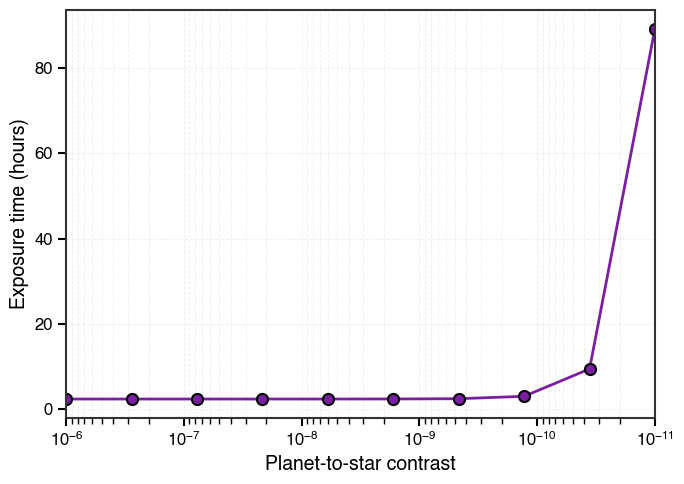

In [10]:
contrasts = np.logspace(-6, -11, 10)
exposure_times = []


for contrast in contrasts:
    params = imaging_params.copy()
    params['Fp/Fs'] = contrast
    # make the parameters be the shape that the code desires 
    parsed_parameters= parse_input.parse_parameters(params)
    texp, validation_output = calculate_texp(parsed_parameters)
    exposure_times.append(texp.to(u.hr).value)


# Make plot
fig, ax1 = plt.subplots()
ax1.semilogx(contrasts, exposure_times, marker='o', markersize=8, linewidth=2,
             color=colors.purple, markerfacecolor=colors.purple, markeredgewidth=1.5,
             markeredgecolor='black')
ax1.set_xlim([1e-6,1e-11])
ax1.set_xlabel('Planet-to-star contrast', fontsize=14, fontweight='bold')
ax1.set_ylabel('Exposure time (hours)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
ax1.tick_params(axis='both', which='minor', width=1, length=4)
ax1.grid(True, which='both', alpha=0.3, linestyle='--', linewidth=0.7)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()



### 3.2 Telescope Diameter

Let's explore the impact of telescope diameter on exposure time:


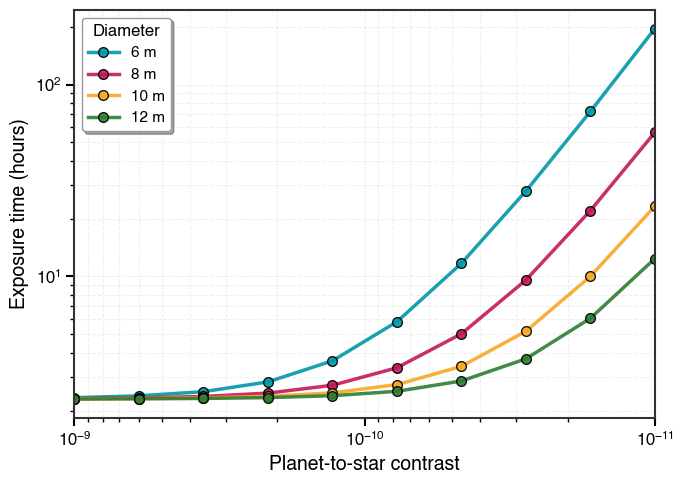

In [11]:
fig = plt.figure()

contrasts=np.logspace(-9, -11, 10)

for idx, diam in enumerate([6,8,10,12]):
    exposure_times=[]
    for contrast in np.logspace(-9, -11, 10):
        params = imaging_params.copy()
        params['Fp/Fs']= contrast
        params['diameter'] = diam
        parsed_parameters= parse_input.parse_parameters(params)
        texp, validation_output = calculate_texp(parsed_parameters)

        exposure_times.append(texp.to(u.hr).value)

    plt.loglog(contrasts, exposure_times, marker='o', label=f'{diam} m',
               markersize=7, linewidth=2.5, color=colors[idx],
               markeredgewidth=1, markeredgecolor='black', alpha=0.9)

plt.xlabel('Planet-to-star contrast', fontsize=14, fontweight='bold')
plt.ylabel('Exposure time (hours)', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
plt.xlim(1e-9,1e-11)
plt.grid(True, which='both', alpha=0.3, linestyle='--', linewidth=0.8)
plt.legend(title='Diameter', fontsize=11, title_fontsize=12, frameon=True,
           fancybox=True, shadow=True, loc='best')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()



### 3.3 Distance and contrast
Let's change distance from the star and planet contrast. 

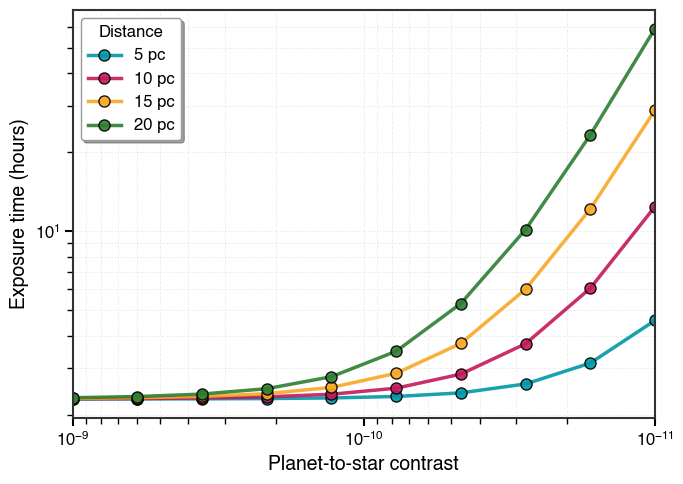

In [12]:
fig, ax = plt.subplots()
contrasts=np.logspace(-9, -11, 10)

for idx, dist in enumerate([5,10,15,20]):
    exposure_times=[]
    for contrast in np.logspace(-9, -11, 10):
        params['Fp/Fs']=contrast
        params['distance']=dist
        # make the parameters be the shape that the code desires 
        parsed_parameters= parse_input.parse_parameters(params)
        texp, validation_output = calculate_texp(parsed_parameters)
        exposure_times.append(texp.to(u.hr).value)


   
    # Primary x-axis (contrast)
    ax.loglog(contrasts, exposure_times, marker='o', linewidth=2.5, markersize=8,
              label=f'{dist} pc', color=colors[idx], markeredgewidth=1,
              markeredgecolor='black', alpha=0.9)
ax.set_xlim([1e-9,1e-11])
ax.set_xlabel('Planet-to-star contrast', fontsize=14, fontweight='medium')
ax.set_ylabel('Exposure time (hours)', fontsize=14, fontweight='medium')
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
ax.tick_params(axis='both', which='minor', width=1, length=4)
ax.legend(frameon=True, shadow=True, fancybox=True, fontsize=12,
          title='Distance', title_fontsize=12)
ax.grid(True, which='both', alpha=0.3, linestyle='--', linewidth=0.7)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.tight_layout()


### 3.4 Separation

Now let's change the separation of the planet and see how the exposure time changes. Note: there will be some errors!

[pyEDITH] ERROR [2026-05-15 16:35:10,658] Planet outside OWA or inside IWA. Hardcoded infinity results.


[pyEDITH] ERROR [2026-05-15 16:35:12,262] Planet outside coronagraph YIP image. Hardcoded infinity results.


[pyEDITH] ERROR [2026-05-15 16:35:12,359] Planet outside coronagraph YIP image. Hardcoded infinity results.


[pyEDITH] ERROR [2026-05-15 16:35:12,454] Planet outside coronagraph YIP image. Hardcoded infinity results.


[pyEDITH] ERROR [2026-05-15 16:35:12,550] Planet outside coronagraph YIP image. Hardcoded infinity results.


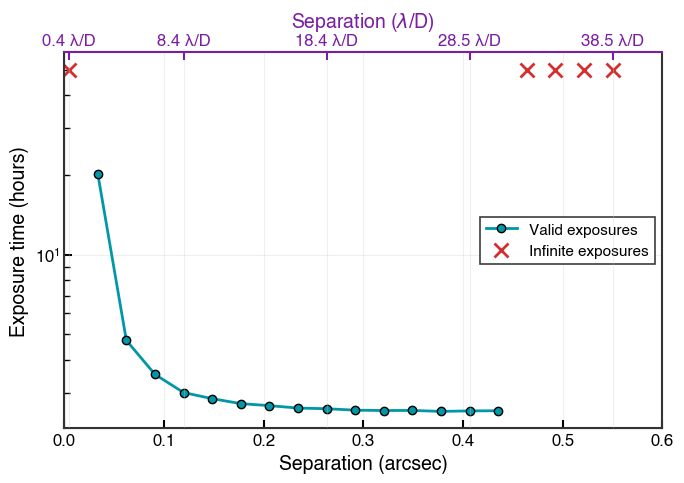

In [13]:
separations = np.linspace(0.005, 0.55, 20)  # arcsec 

exposure_times = []

for sep in separations:
    params = imaging_params.copy()
    params['separation'] = sep
    parsed_parameters= parse_input.parse_parameters(params)

    texp, _ = calculate_texp(parsed_parameters)
    exposure_times.append(texp.to(u.hr)[0].value)

fig, ax1 = plt.subplots()

# Primary x-axis (separation arcsec)
ax1.plot(separations, exposure_times, marker='o', label='Valid exposures',
         markersize=6, linewidth=2, color=colors.cyan, markerfacecolor=colors.cyan,
         markeredgecolor='black', markeredgewidth=1)
ax1.plot(separations[np.isinf(exposure_times)],
         np.ones_like(separations)[np.isinf(exposure_times)]*50,
         marker='x', linestyle='', color=colors.red, label='Infinite exposures',
         markersize=10, markeredgewidth=2)

ax1.set_xlabel('Separation (arcsec)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Exposure time (hours)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=12, direction='in',
                width=1.5, length=6, top=False)
ax1.tick_params(axis='both', which='minor', direction='in', width=1,
                length=4, top=False)
ax1.set_xlim(0, 0.6)
ax1.set_yscale('log')

for spine in ['bottom','left','right']:
    ax1.spines[spine].set_visible(True)
    ax1.spines[spine].set_linewidth(1.5)

# Secondary x-axis (lambda/D)
separations_lod = arcsec_to_lambda_d(separations*ARCSEC,
                                     observation.wavelength[0].to(LENGTH),
                                     observatory.telescope.diameter.to(LENGTH))

num_ticks = 5 
tick_indices = np.linspace(0, len(separations) - 1, num_ticks, dtype=int)
reduced_separations = [separations[i] for i in tick_indices]
reduced_separations_lod = [separations_lod[i] for i in tick_indices]

ax2 = ax1.twiny()
ax2.set_xticks(reduced_separations)
ax2.set_xticklabels([f'{m:.1f}' for m in reduced_separations_lod],color=colors.purple)
ax2.set_xlim(ax1.get_xlim())
ax2.set_xlabel(r'Separation ($\lambda$/D)', fontsize=14, fontweight='bold',color=colors.purple)
ax2.tick_params(axis='x', which='major', labelsize=12, direction='in',
                width=1.5, length=6,color=colors.purple)


for spine in ['top']:
    ax2.spines[spine].set_visible(True)
    ax2.spines[spine].set_linewidth(1.5)
    ax2.spines[spine].set_color(colors.purple)






legend = ax1.legend(loc='best', frameon=True, fancybox=False, shadow=False,
                   fontsize=11, edgecolor='#333333', framealpha=0.95)
legend.get_frame().set_linewidth(1.2)

plt.tight_layout()


What if you have a planet and you want to vary the physical distance instead of calculating the corresponding separation? You can also use the keyword ``semimajor_axis'' and pyEDITH will calculate the separation internally.

[pyEDITH] ERROR [2026-05-15 16:35:12,754] Planet outside OWA or inside IWA. Hardcoded infinity results.


[pyEDITH] ERROR [2026-05-15 16:35:13,744] Planet outside coronagraph YIP image. Hardcoded infinity results.


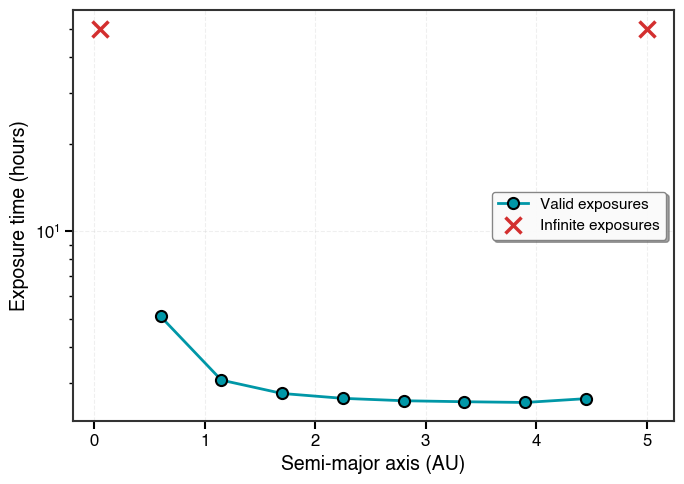

In [14]:
semimajor_axes = np.linspace(0.05, 5, 10)  # AU 

exposure_times = []

for a in semimajor_axes:
    params = imaging_params.copy()
    del params['separation']
    params['semimajor_axis'] = a 
    parsed_parameters= parse_input.parse_parameters(params)

    texp, _ = calculate_texp(parsed_parameters)
    exposure_times.append(texp.to(u.hr)[0].value)



fig = plt.figure(dpi=100)
ax = plt.gca()
plt.plot(semimajor_axes, exposure_times, marker='o', label='Valid exposures',
         markersize=8, linewidth=2, color=colors.cyan, markerfacecolor=colors.cyan,
         markeredgecolor='black', markeredgewidth=1.5)
plt.plot(semimajor_axes[np.isinf(exposure_times)],
         np.ones_like(semimajor_axes)[np.isinf(exposure_times)]*50,
         marker='x', linestyle='', color=colors.red, label='Infinite exposures',
         markersize=12, markeredgewidth=2.5)

plt.xlabel('Semi-major axis (AU)', fontsize=14, fontweight='bold')
plt.ylabel('Exposure time (hours)', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
plt.yscale('log')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

plt.legend(loc='best', fontsize=11, frameon=True, shadow=True, fancybox=True,
           framealpha=0.95, edgecolor='gray')

plt.tight_layout()


### 3.5 PSF Truncation Ratio
Also, we can test the effect of varying the PSF trunction ratio. There should exist a PSF truncation ratio that minimizes exposure time and maximizes SNR (and it should be around 0.3). Let's test this:

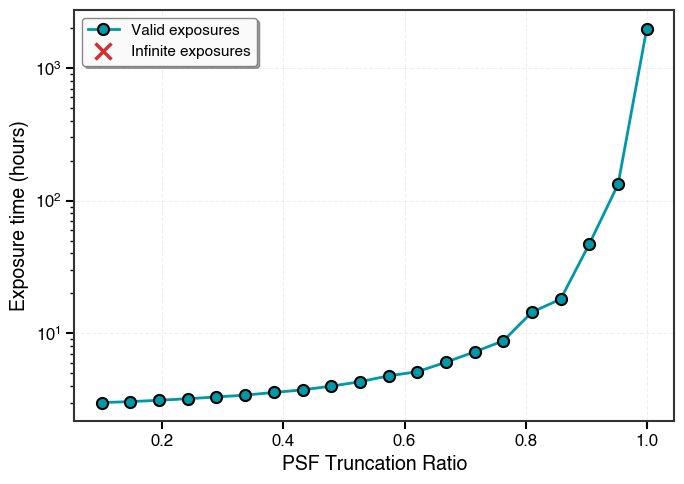

In [15]:
psfratios = np.linspace(0.1, 1, 20)   

exposure_times = []

for ratio in psfratios:
    params = imaging_params.copy()
    params['psf_trunc_ratio'] = ratio
    parsed_parameters= parse_input.parse_parameters(params)
    texp, _ = calculate_texp(parsed_parameters)
    exposure_times.append(texp.to(u.hr)[0].value)

fig = plt.figure(dpi=100)
ax = plt.gca()
plt.semilogy(psfratios, exposure_times, marker='o', label='Valid exposures',
         markersize=8, linewidth=2, color=colors.cyan, markerfacecolor=colors.cyan,
         markeredgecolor='black', markeredgewidth=1.5)
plt.semilogy(psfratios[np.isinf(exposure_times)],
         np.ones_like(psfratios)[np.isinf(exposure_times)]*10,
         marker='x', linestyle='', color=colors.red, label='Infinite exposures',
         markersize=12, markeredgewidth=2.5)

plt.xlabel('PSF Truncation Ratio', fontsize=14, fontweight='bold')
plt.ylabel('Exposure time (hours)', fontsize=14, fontweight='bold')

plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

plt.legend(loc='best', fontsize=11, frameon=True, shadow=True, fancybox=True,
           framealpha=0.95, edgecolor='gray')
plt.tight_layout()
plt.show()


Let's try with the SNR calculation instead.

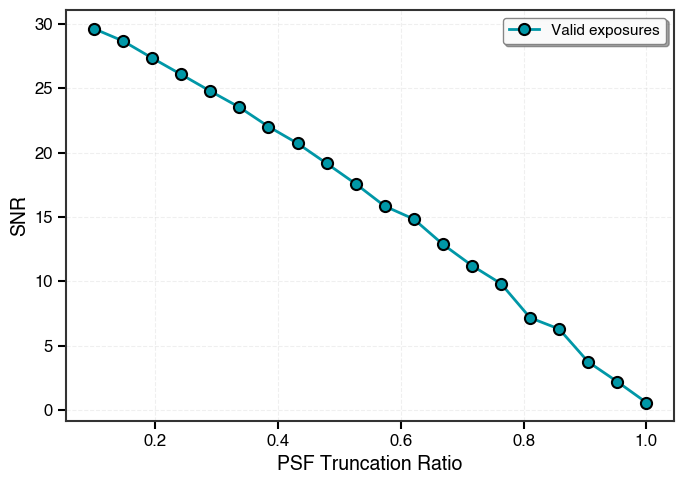

In [16]:
# SNR Case
 
psfratios = np.linspace(0.1, 1, 20)   
exptime=15*u.hr
snrs = []

for ratio in psfratios:
    params = imaging_params.copy()
    params['psf_trunc_ratio'] = ratio
    parsed_parameters= parse_input.parse_parameters(params)
    snr,_ = calculate_snr(parsed_parameters,exptime)
    snrs.append(snr[0].value)

# MAKE PLOT
fig = plt.figure(dpi=100)
ax = plt.gca()

plt.plot(psfratios, snrs, marker='o', label='Valid exposures',
         markersize=8, linewidth=2, color=colors.cyan, markerfacecolor=colors.cyan,
         markeredgecolor='black', markeredgewidth=1.5)

plt.xlabel('PSF Truncation Ratio', fontsize=14, fontweight='bold')
plt.ylabel('SNR', fontsize=14, fontweight='bold')

plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

plt.legend(loc='best', fontsize=11, frameon=True, shadow=True, fancybox=True,
           framealpha=0.95, edgecolor='gray')
plt.tight_layout()
plt.show()

# SNR maximized at 0.3, just like it should! 